## Parametric experiment on g.d. 

In [79]:
# import all libraries

import numpy as np
import matplotlib.pyplot as plt

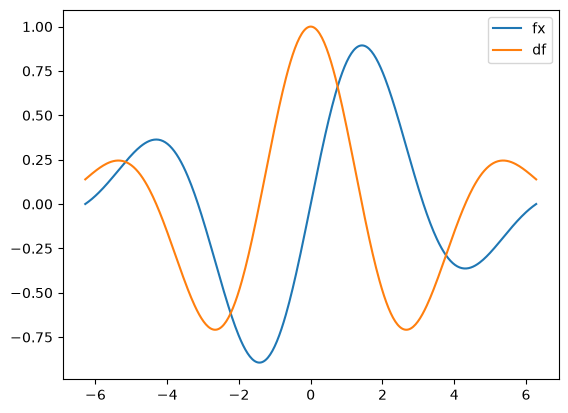

In [80]:
# the function
x = np.linspace(-2*np.pi,2*np.pi,401)
fx = np.sin(x) * np.exp(-x**2*.05)

# and its derivative

df = np.cos(x) * np.exp(-x**2*.05) + np.sin(x)*(-x*.1)*np.exp(-x**2*.05)

# plot the variables
plt.plot(x,fx,x,df)
plt.legend(['fx','df'])
plt.show()

In [148]:
# function
def fx(x):
    return np.sin(x) * np.exp(-x**2*.05)

# derivative

def deriv(x):
    return np.cos(x) * np.exp(-x**2*.05) + np.sin(x)*(-x*.1)*np.exp(-x**2*.05)

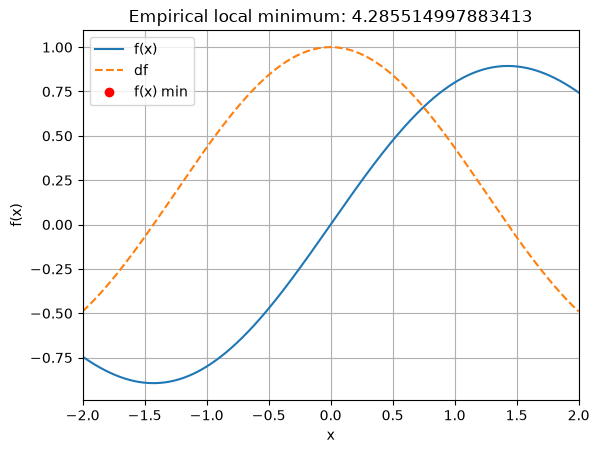

In [147]:
# random starting point

localmin = np.random.choice(x,1) # escolhemos uma array de único elemento, ponto x = random

# learning parameters
learning_rate = 0.01
training_epochs = 1000

for i in range(training_epochs):
    grad = deriv(localmin)
    localmin = localmin - grad * learning_rate

# plot the results
plt.plot(x,fx(x),x,deriv(x),'--')
plt.plot(localmin,deriv(localmin),'ro')
plt.plot(localmin,fx(localmin),'ro')

plt.xlim(x[[0,-1]])
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend(['f(x)','df','f(x) min'])
plt.title('Empirical local minimum: %s'%localmin[0])
plt.show()

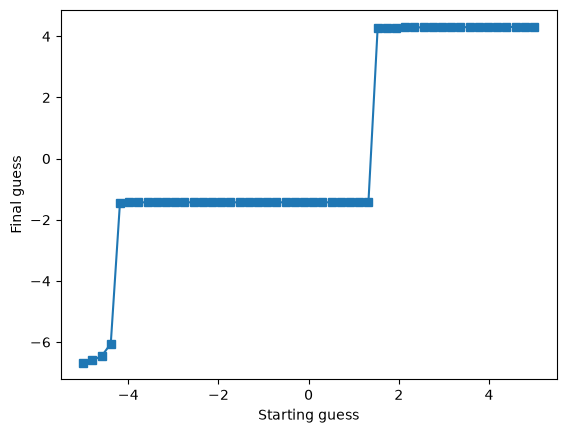

In [120]:
# 1. Experiment
# desenvolver experimentos iniciais para compreender melhor o aprendizado do código.

startlocs = np.linspace(-5,5,50) # aqui estamos avaliando diferentes pontos que começam o experimento entre -5 e 5.
finalres = np.zeros(len(startlocs))

# loop over starting points
for idx,localmin in enumerate(startlocs):

    # run through training
    for i in range(training_epochs):
        grad = deriv(localmin)
        localmin = localmin - grad * learning_rate

    # store the final guess
    finalres[idx] = localmin

# plot the results
plt.plot(startlocs,finalres, 's-')
plt.xlabel('Starting guess')
plt.ylabel('Final guess')
plt.show()


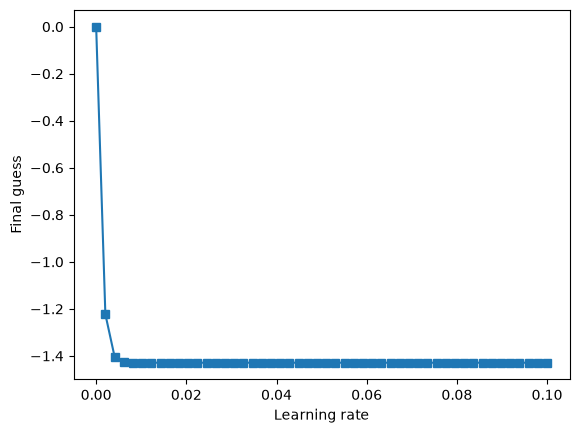

In [121]:
# 2. Experiment: systematically varying the learning rate

# agora mantemos o fixado o parâmetro de posição do mínimo local, inicialmente, e variamos a taxa de aprendizado.

learningrates = np.linspace(1e-10,1e-1,50)
finalres = np.zeros(len(learningrates))

# loop over learning rates
for idx,learningRate in enumerate(learningrates):

    # force starting guess to 0
    localmin = 0

    # run through training
    for i in range(training_epochs):
        grad = deriv(localmin)
        localmin = localmin - learningRate * grad

    # stoe the final guess
    finalres[idx] = localmin #note como começamos em 0, a posição do localmin já indica a distância percorrida pelo algoritmo.

# plot the results
plt.plot(learningrates,finalres, 's-') 
plt.xlabel('Learning rate')
plt.ylabel('Final guess')
plt.show()

# podemos usar o gráfico resultando como uma forma de minimizar o tempo/CPU/GPU gasto e maximizar a taxa de aprendizado.

In [122]:
# Experimento 3: interaction between learning rate and training epochs

# setup parametes
learningrates = np.linspace(1e-10,1e-1,50)
training_epochs = np.round(np.linspace(10,500,40))

# initializa matrix to store results

finalres = np.zeros((len(learningrates),len(training_epochs)))

# loop over larning rates
for Lidx,learningRate in enumerate(learningrates):

    # loop over training epochs
    for Eidx,trainEpochs in enumerate(training_epochs):

        # run through training (again fixing starting location)
        localmin = 0
        for i in range(int(trainEpochs)):
            grad = deriv(localmin)
            localmin = localmin - learningRate * grad

        # store the final guess
        finalres[Lidx,Eidx] = localmin

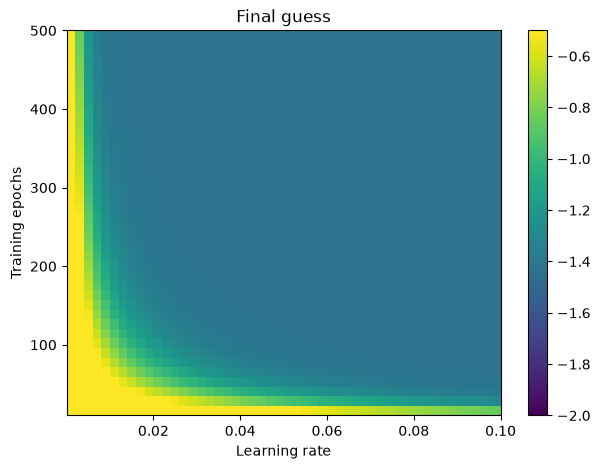

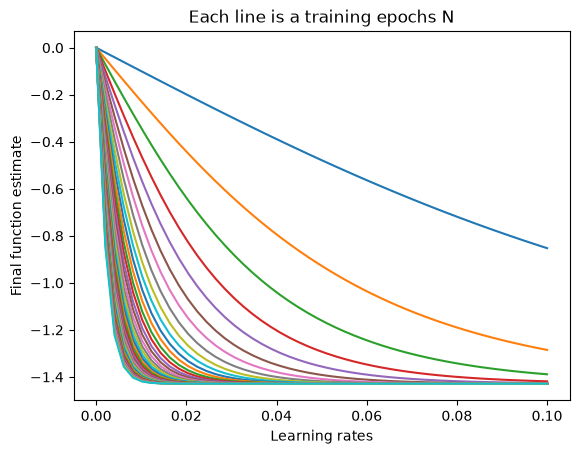

In [130]:
# plot the results

fig,ax = plt.subplots(figsize=(7,5))

plt.imshow(finalres.T,extent=[learningrates[0],learningrates[-1],training_epochs[0],training_epochs[-1]],
           aspect='auto',origin='lower',vmin=-2.0,vmax=-0.5)

plt.xlabel('Learning rate')
plt.ylabel('Training epochs')
plt.title('Final guess')
plt.colorbar()
plt.show()

# another visualization
plt.plot(learningrates,finalres)
plt.xlabel('Learning rates')
plt.ylabel('Final function estimate')
plt.title('Each line is a training epochs N')
plt.show()

1) No experimento 3, defina a posição inicial como 1,6. Execute novamente o experimento e gere a imagem. Você precisará reajustar
os limites de cor da figura; verifique os gráficos de linha no início do código para determinar uma faixa de cores adequada. O novo
valor inicial altera suas conclusões sobre a interação entre a taxa de aprendizado e as épocas de treinamento?

2) No mesmo experimento, altere agora a posição inicial para um valor aleatório (use o código: `np.random.choice(x,1)`). Como estão
esses resultados? Você ficou surpreso? Os resultados deste experimento ainda são interpretáveis ​​e o que isso lhe diz
sobre a execução de experimentos em DL (Aprendizado Profundo)?

---
Não, apenas modifica o caso, pois estamos coletando um mínimo local e não global, justamente porque o ponto x=1.6 é um máximo e o código tende ao mínimo local. Mas podemos notar que a relação entre taxa de aprendizado e época apresenta comportamento semelhante.

A taxa de aprendizado fica mais ruidosa e no caso do gráfico de calor, temos que ficar reorientando a escala, para observar os dados, mas apresenta aspectos semelhantes. 


## Codechallenge: fixed vs dynamic learning rate

podemos aplicar o mesmo código inicial (1D) avaliando o que ocorre quando alteramos o learning_rate a cada iteração

In [281]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt

In [282]:
# function (as a function)
def fx(x):
    return 3*x**2 - 3*x + 4

# your derivative
def deriv(x):
    return 6*x - 3

In [285]:
# random starting point
localmin = np.random.choice(x,1)
initval = localmin[:] # store the initial value

# learning parameters
learning_rate = .01
training_epochs = 50

# run through training and store all the results
modelparamsFixed = np.zeros((training_epochs,3))
for i in range(training_epochs):

  # compute gradient
  grad = deriv(localmin)

  # non-adaptive learning rate
  lr = learning_rate

  # update parameter according to g.d.
  localmin = localmin - lr*grad

  # store the parameters
  modelparamsFixed[i,0] = localmin[0]
  modelparamsFixed[i,1] = grad[0]
  modelparamsFixed[i,2] = lr

In [286]:
# random starting point
localmin = np.random.choice(x,1)
initval = localmin[:] # store the initial value

# learning parameters
learning_rate = .01
training_epochs = 50

# run through training and store all the results
modelparamsGrad = np.zeros((training_epochs,3))
for i in range(training_epochs):

  # compute gradient
  grad = deriv(localmin)

  # adapt the learning rate according to the gradient
  lr = learning_rate*np.abs(grad)

  # update parameter according to g.d.
  localmin = localmin - lr*grad

  # store the parameters
  modelparamsGrad[i,0] = localmin[0]
  modelparamsGrad[i,1] = grad[0]
  modelparamsGrad[i,2] = lr[0]

In [287]:
# redefine parameters
learning_rate = .1
localmin = initval

# run through training and store all the results
modelparamsTime = np.zeros((training_epochs,3))
for i in range(training_epochs):
  grad = deriv(localmin)
  lr = learning_rate*(1-(i+1)/training_epochs)
  localmin = localmin - lr*grad
  modelparamsTime[i,0] = localmin[0]
  modelparamsTime[i,1] = grad[0]
  modelparamsTime[i,2] = lr

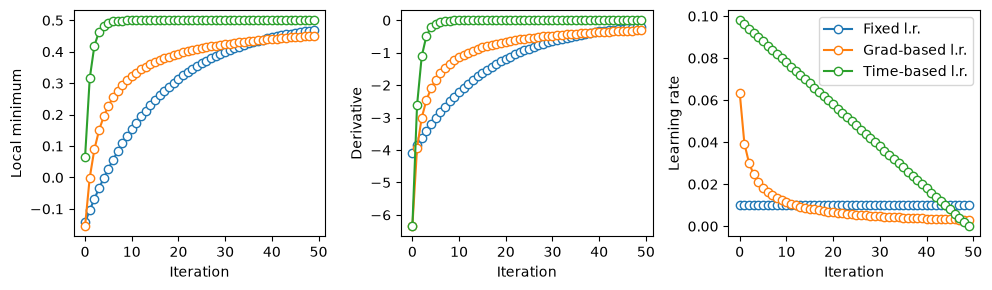

In [288]:
fig,ax = plt.subplots(1,3,figsize=(10,3))

# generate the plots
for i in range(3):
  ax[i].plot(modelparamsFixed[:,i],'o-',markerfacecolor='w')
  ax[i].plot(modelparamsGrad[:,i],'o-',markerfacecolor='w')
  ax[i].plot(modelparamsTime[:,i],'o-',markerfacecolor='w')
  ax[i].set_xlabel('Iteration')

ax[0].set_ylabel('Local minimum')
ax[1].set_ylabel('Derivative')
ax[2].set_ylabel('Learning rate')
ax[2].legend(['Fixed l.r.','Grad-based l.r.','Time-based l.r.'])

plt.tight_layout()
plt.show()